# Kirk Spread Option — Static Vega Hedge Comparison

**Strategy A** — ATM call on S₁ + ATM put on S₂ + futures  
**Strategy B** — Symmetric strangle on each leg + futures  
&emsp; Strangle: call @ S·α, put @ S/α  →  geometric mean = S  (log-symmetric around forward)

In [18]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd
from math import sqrt

# ── Market parameters ──────────────────────────────────────────────
S1_0   = 25.0    # asset 1 spot
S2_0   = 25.0    # asset 2 spot
K      = 0.0     # spread option strike (Margrabe)
sigma1 = 0.30
sigma2 = 0.30
rho    = 0.90
T      = 1.0     # maturity (years)
r      = 0.0     # risk-free rate

# ── Strangle OTM factor ────────────────────────────────────────────
# call at S*alpha, put at S/alpha  →  sqrt(K_call * K_put) = S
alpha  = 1.30

# ── Heatmap grid ───────────────────────────────────────────────────
N_G  = 35
s1g  = np.linspace(18., 35., N_G)
s2g  = np.linspace(18., 35., N_G)
s1pf, s2pf = np.meshgrid(s1g, s2g, indexing='ij')
s1f  = s1pf.ravel()
s2f  = s2pf.ravel()

In [19]:
# ── Pricing & Greeks ───────────────────────────────────────────────
_N, _n = norm.cdf, norm.pdf


def _d1d2(S, K_, sig):
    d1 = (np.log(S / K_) + 0.5 * sig**2 * T) / (sig * sqrt(T))
    return d1, d1 - sig * sqrt(T)


def bs_call(S, K_, sig):
    """Black-Scholes call price and Greeks (r=0)."""
    d1, d2 = _d1d2(S, K_, sig)
    return dict(
        price = S * _N(d1) - K_ * _N(d2),
        delta = _N(d1),
        gamma = _n(d1) / (S * sig * sqrt(T)),
        vega  = S * _n(d1) * sqrt(T),
    )


def bs_put(S, K_, sig):
    """Black-Scholes put price and Greeks (r=0)."""
    d1, d2 = _d1d2(S, K_, sig)
    return dict(
        price = K_ * _N(-d2) - S * _N(-d1),
        delta = _N(d1) - 1.0,
        gamma = _n(d1) / (S * sig * sqrt(T)),
        vega  = S * _n(d1) * sqrt(T),
    )


def kirk(S1, S2):
    """Margrabe (K=0) spread option price and Greeks."""
    sig_k = sqrt(sigma1**2 - 2*rho*sigma1*sigma2 + sigma2**2)
    sqT   = sqrt(T)
    d1    = (np.log(S1 / S2) + 0.5 * sig_k**2 * T) / (sig_k * sqT)
    d2    = d1 - sig_k * sqT
    vk    = S1 * _n(d1) * sqT          # total vega w.r.t. sig_k
    return dict(
        price   = S1 * _N(d1) - S2 * _N(d2),
        delta1  =  _N(d1),
        delta2  = -_N(d2),
        gamma11 = _n(d1) / (S1 * sig_k * sqT),
        gamma22 = S1 * _n(d1) / (S2**2 * sig_k * sqT),  # via S1·n(d1)=S2·n(d2)
        vega1   = vk * (sigma1 - rho * sigma2) / sig_k,
        vega2   = vk * (sigma2 - rho * sigma1) / sig_k,
    )

In [20]:
# ── OLS hedge: find (h, nF) minimising residual [delta, gamma, vega] ──

def _ols_pair(sp_d, sp_g, sp_v, inst_d, inst_g, inst_v):
    """
    Solve: min ||[delta, gamma, vega]_spread + h*inst + nF*future||^2
    h  = instrument size,   nF = futures notional (delta only).
    Each Greek block is normalised so all three contribute equally.
    """
    n    = len(sp_d)
    sc_d = max(float(np.abs(sp_d).max()), 1e-10)
    sc_g = max(float(np.abs(sp_g).max()), 1e-10)
    sc_v = max(float(np.abs(sp_v).max()), 1e-10)

    A = np.zeros((3 * n, 2))
    b = np.zeros(3 * n)

    A[:n,    0] = inst_d / sc_d;  A[:n, 1] = 1.0 / sc_d;  b[:n]    = -sp_d / sc_d
    A[n:2*n, 0] = inst_g / sc_g;                           b[n:2*n] = -sp_g / sc_g
    A[2*n:,  0] = inst_v / sc_v;                           b[2*n:]  = -sp_v / sc_v

    c, *_ = np.linalg.lstsq(A, b, rcond=None)
    return float(c[0]), float(c[1])

In [21]:
# ── Compute spread option Greeks on grid ───────────────────────────
sp = kirk(s1f, s2f)

# ── Strategy A: ATM ────────────────────────────────────────────────
c1a = bs_call(s1f, S1_0, sigma1)   # ATM call on S1
p2a = bs_put( s2f, S2_0, sigma2)   # ATM put  on S2

h1a, nF1a = _ols_pair(sp["delta1"], sp["gamma11"], sp["vega1"],
                       c1a["delta"],  c1a["gamma"],  c1a["vega"])
h2a, nF2a = _ols_pair(sp["delta2"], sp["gamma22"], sp["vega2"],
                       p2a["delta"],  p2a["gamma"],  p2a["vega"])

V1a = sp["vega1"] + h1a * c1a["vega"]   # residual vega1
V2a = sp["vega2"] + h2a * p2a["vega"]   # residual vega2

# ── Strategy B: symmetric strangle ────────────────────────────────
# S1 strangle: call @ S1*alpha, put @ S1/alpha
K1c, K1p = S1_0 * alpha, S1_0 / alpha
# S2 strangle: call @ S2*alpha, put @ S2/alpha
K2c, K2p = S2_0 * alpha, S2_0 / alpha

c1b = bs_call(s1f, K1c, sigma1);  p1b = bs_put(s1f, K1p, sigma1)
c2b = bs_call(s2f, K2c, sigma2);  p2b = bs_put(s2f, K2p, sigma2)

# Equal-size strangle: combined Greeks = call + put
str1 = {k: c1b[k] + p1b[k] for k in ("delta", "gamma", "vega")}
str2 = {k: c2b[k] + p2b[k] for k in ("delta", "gamma", "vega")}

h1b, nF1b = _ols_pair(sp["delta1"], sp["gamma11"], sp["vega1"],
                       str1["delta"],  str1["gamma"],  str1["vega"])
h2b, nF2b = _ols_pair(sp["delta2"], sp["gamma22"], sp["vega2"],
                       str2["delta"],  str2["gamma"],  str2["vega"])

V1b = sp["vega1"] + h1b * str1["vega"]   # residual vega1
V2b = sp["vega2"] + h2b * str2["vega"]   # residual vega2

print(f"Strategy A:  h1={h1a:+.4f}  h2={h2a:+.4f}  nF1={nF1a:+.4f}  nF2={nF2a:+.4f}")
print(f"Strategy B:  h1={h1b:+.4f}  h2={h2b:+.4f}  nF1={nF1b:+.4f}  nF2={nF2b:+.4f}")
print(f"Strangle strikes:  S1 call@{K1c:.2f} / put@{K1p:.2f}  |  S2 call@{K2c:.2f} / put@{K2p:.2f}")

Strategy A:  h1=-0.1399  h2=-0.1399  nF1=-0.4281  nF2=+0.4320
Strategy B:  h1=-0.0875  h2=-0.0875  nF1=-0.4986  nF2=+0.5014
Strangle strikes:  S1 call@32.50 / put@19.23  |  S2 call@32.50 / put@19.23


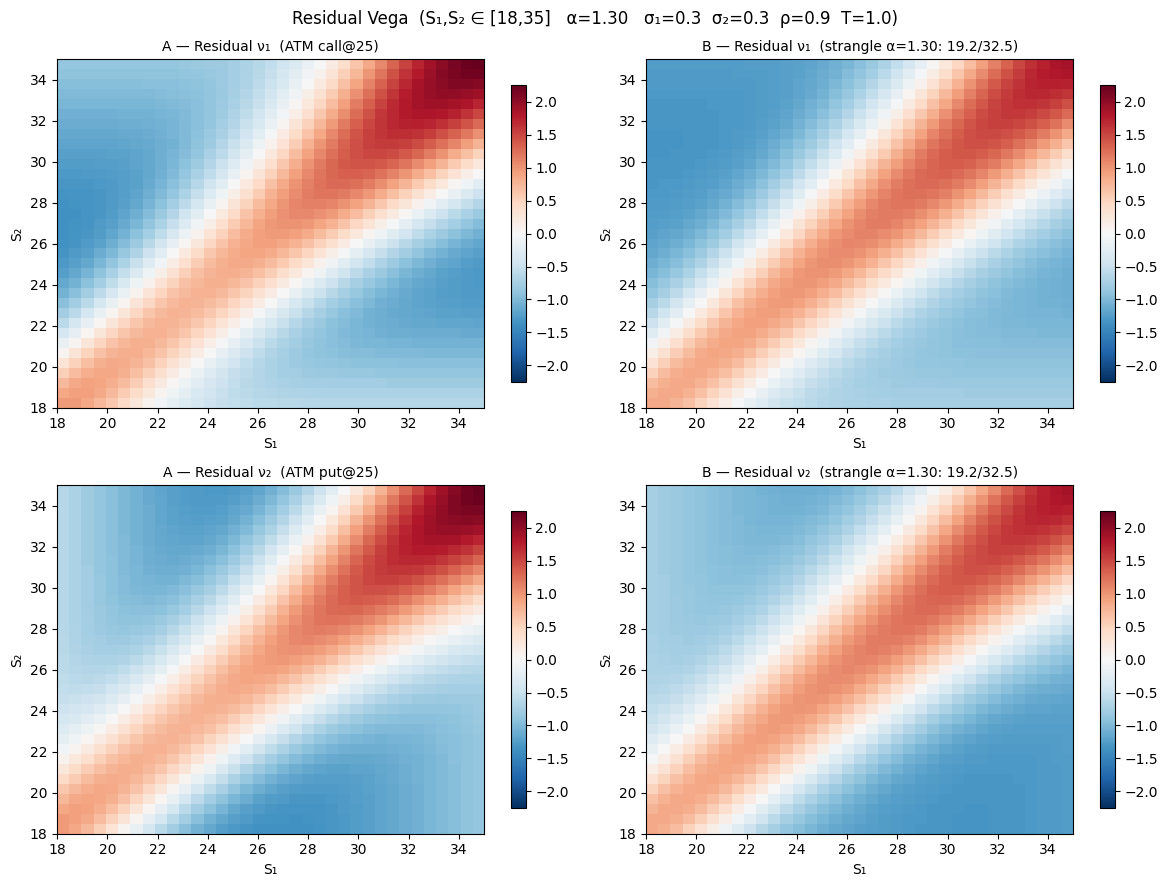

In [22]:
# ── Residual vega heatmaps ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(
    f"Residual Vega  (S₁,S₂ ∈ [18,35]   α={alpha:.2f}   "
    f"σ₁={sigma1}  σ₂={sigma2}  ρ={rho}  T={T})",
    fontsize=12,
)


def _hm(ax, data, title, vlim):
    im = ax.imshow(
        data.reshape(N_G, N_G), origin="lower",
        extent=[18, 35, 18, 35], aspect="auto",
        vmin=-vlim, vmax=vlim, cmap="RdBu_r",
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("S₁");  ax.set_ylabel("S₂")
    plt.colorbar(im, ax=ax, shrink=0.85)


v1_lim = max(np.abs(V1a).max(), np.abs(V1b).max())
v2_lim = max(np.abs(V2a).max(), np.abs(V2b).max())

_hm(axes[0, 0], V1a, f"A — Residual ν₁  (ATM call@{S1_0:.0f})", v1_lim)
_hm(axes[0, 1], V1b, f"B — Residual ν₁  (strangle α={alpha:.2f}: {K1p:.1f}/{K1c:.1f})", v1_lim)
_hm(axes[1, 0], V2a, f"A — Residual ν₂  (ATM put@{S2_0:.0f})", v2_lim)
_hm(axes[1, 1], V2b, f"B — Residual ν₂  (strangle α={alpha:.2f}: {K2p:.1f}/{K2c:.1f})", v2_lim)

plt.tight_layout()
plt.show()

In [ ]:
# ── Initial costs ──────────────────────────────────────────────────
sp0   = kirk(S1_0, S2_0)
pr_sp = float(np.squeeze(sp0["price"]))

pr_c1a = float(np.squeeze(bs_call(S1_0, S1_0, sigma1)["price"]))
pr_p2a = float(np.squeeze(bs_put( S2_0, S2_0, sigma2)["price"]))
net_A  = pr_sp + h1a * pr_c1a + h2a * pr_p2a

pr_c1b = float(np.squeeze(bs_call(S1_0, K1c, sigma1)["price"]))
pr_p1b = float(np.squeeze(bs_put( S1_0, K1p, sigma1)["price"]))
pr_c2b = float(np.squeeze(bs_call(S2_0, K2c, sigma2)["price"]))
pr_p2b = float(np.squeeze(bs_put( S2_0, K2p, sigma2)["price"]))
net_B  = pr_sp + h1b * (pr_c1b + pr_p1b) + h2b * (pr_c2b + pr_p2b)

# ── Side-by-side cost table ─────────────────────────────────────────
nan = float("nan")

def _row(label, ra, ua, rb, ub):
    ca = ra * ua if ra is not None else nan
    cb = rb * ub if rb is not None else nan
    return {
        "instrument":  label,
        "A  ratio":    ra  if ra is not None else nan,
        "A  unit px":  ua  if ua is not None else nan,
        "A  cost":     ca,
        "B  ratio":    rb  if rb is not None else nan,
        "B  unit px":  ub  if ub is not None else nan,
        "B  cost":     cb,
    }

rows = [
    _row(f"S₁ call  A:ATM@{S1_0:.0f}  B:OTM@{K1c:.2f}",  h1a, pr_c1a,  h1b, pr_c1b),
    _row(f"S₁ put   A: —       B:OTM@{K1p:.2f}",          None, None,   h1b, pr_p1b),
    _row(f"S₂ call  A: —       B:OTM@{K2c:.2f}",          None, None,   h2b, pr_c2b),
    _row(f"S₂ put   A:ATM@{S2_0:.0f}  B:OTM@{K2p:.2f}",   h2a, pr_p2a,  h2b, pr_p2b),
]

sep = {c: nan for c in ("instrument","A  ratio","A  unit px","A  cost","B  ratio","B  unit px","B  cost")}
sep["instrument"] = "─" * 55

totals = [
    sep,
    {"instrument": "hedge subtotal",
     "A  ratio": nan, "A  unit px": nan, "A  cost": h1a*pr_c1a + h2a*pr_p2a,
     "B  ratio": nan, "B  unit px": nan, "B  cost": h1b*(pr_c1b+pr_p1b) + h2b*(pr_c2b+pr_p2b)},
    {"instrument": "spread option",
     "A  ratio": nan, "A  unit px": nan, "A  cost": pr_sp,
     "B  ratio": nan, "B  unit px": nan, "B  cost": pr_sp},
    sep,
    {"instrument": "NET COST",
     "A  ratio": nan, "A  unit px": nan, "A  cost": net_A,
     "B  ratio": nan, "B  unit px": nan, "B  cost": net_B},
]

ct = pd.DataFrame(rows + totals).set_index("instrument")
fmt = lambda x: f"{x:+.4f}" if pd.notna(x) else "    —   "
print(ct.to_string(float_format=fmt, na_rep="    —   "))

In [ ]:
# ── Scoring ────────────────────────────────────────────────────────

def _score(V1, V2, net_cost, label):
    r1  = float(np.sqrt(np.mean(V1**2)))
    r2  = float(np.sqrt(np.mean(V2**2)))
    tot = r1 + r2
    return pd.Series({
        "rmse_ν1":    r1,
        "rmse_ν2":    r2,
        "rmse_total": tot,
        "max_ν1":     float(np.abs(V1).max()),
        "max_ν2":     float(np.abs(V2).max()),
        "net_cost":   net_cost,
        "efficiency": tot / max(abs(net_cost), 1e-8),
    }, name=label)


# unhedged baseline (h=0)
V1_raw = sp["vega1"]
V2_raw = sp["vega2"]
rmse_raw1 = float(np.sqrt(np.mean(V1_raw**2)))
rmse_raw2 = float(np.sqrt(np.mean(V2_raw**2)))
rmse_raw   = rmse_raw1 + rmse_raw2

df = pd.DataFrame([
    _score(V1a, V2a, net_A, f"A  ATM@{S1_0:.0f}"),
    _score(V1b, V2b, net_B, f"B  α={alpha:.2f}"),
])
df.index.name = "Strategy"

# hedge effectiveness = % of vega RMSE removed vs unhedged
df["eff_%"] = (1 - df["rmse_total"] / rmse_raw) * 100

print("Unhedged baseline:")
print(f"  rmse_ν1={rmse_raw1:+.4f}  rmse_ν2={rmse_raw2:+.4f}  rmse_total={rmse_raw:+.4f}")
print()
print("Hedge Quality Scores  (lower RMSE = better)\n")
print(df.to_string(float_format=lambda x: f"{x:+.4f}"))

BAR = 20
print("\nWinner per metric:")
for col in [c for c in df.columns if c != "eff_%"]:
    vals  = df[col].values
    scale = BAR / max(max(abs(vals)), 1e-8)
    bA    = "█" * max(1, int(abs(vals[0]) * scale))
    bB    = "█" * max(1, int(abs(vals[1]) * scale))
    w     = "A" if vals[0] <= vals[1] else "B"
    print(f"  {col:<14} A={vals[0]:+.4f} {bA:<22} B={vals[1]:+.4f} {bB:<22} → {w}")

print(f"\nHedge effectiveness (% of total vega RMSE removed vs unhedged={rmse_raw:.4f}):")
for strat, row in df.iterrows():
    bar = "█" * int(row["eff_%"] / 2)
    print(f"  {strat}  {row['eff_%']:+.1f}%  {bar}")

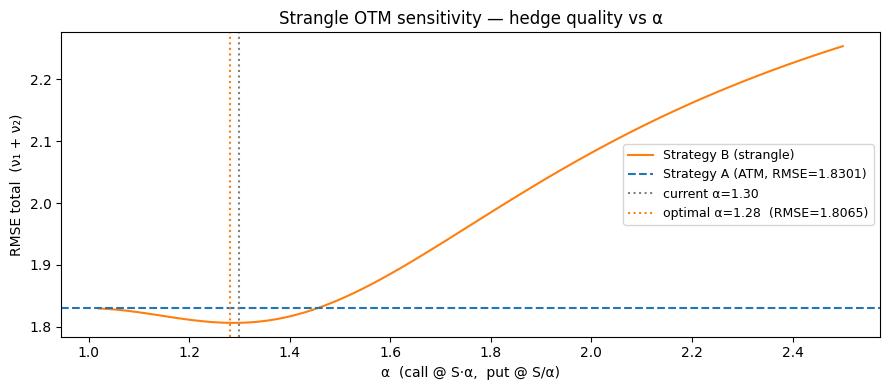

Optimal strangle: α=1.282  call@32.06 / put@19.50
Best B RMSE = 1.8065  vs  A RMSE = 1.8301


In [25]:
# ── Alpha sensitivity: RMSE vs OTM factor ─────────────────────────
alphas = np.linspace(1.02, 2.5, 80)
rmse_B = []

for a in alphas:
    kc1, kp1 = S1_0 * a, S1_0 / a
    kc2, kp2 = S2_0 * a, S2_0 / a

    cb1 = bs_call(s1f, kc1, sigma1);  pb1 = bs_put(s1f, kp1, sigma1)
    cb2 = bs_call(s2f, kc2, sigma2);  pb2 = bs_put(s2f, kp2, sigma2)

    s1_ = {k: cb1[k] + pb1[k] for k in ("delta", "gamma", "vega")}
    s2_ = {k: cb2[k] + pb2[k] for k in ("delta", "gamma", "vega")}

    hh1, _ = _ols_pair(sp["delta1"], sp["gamma11"], sp["vega1"],
                       s1_["delta"], s1_["gamma"], s1_["vega"])
    hh2, _ = _ols_pair(sp["delta2"], sp["gamma22"], sp["vega2"],
                       s2_["delta"], s2_["gamma"], s2_["vega"])

    r1 = float(np.sqrt(np.mean((sp["vega1"] + hh1 * s1_["vega"])**2)))
    r2 = float(np.sqrt(np.mean((sp["vega2"] + hh2 * s2_["vega"])**2)))
    rmse_B.append(r1 + r2)

rmse_A_ref = float(np.sqrt(np.mean(V1a**2))) + float(np.sqrt(np.mean(V2a**2)))
best_idx   = int(np.argmin(rmse_B))
best_alpha = alphas[best_idx]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alphas, rmse_B, color="tab:orange", label="Strategy B (strangle)")
ax.axhline(rmse_A_ref, color="tab:blue", linestyle="--",
           label=f"Strategy A (ATM, RMSE={rmse_A_ref:.4f})")
ax.axvline(alpha, color="gray", linestyle=":", label=f"current α={alpha:.2f}")
ax.axvline(best_alpha, color="tab:orange", linestyle=":",
           label=f"optimal α={best_alpha:.2f}  (RMSE={rmse_B[best_idx]:.4f})")
ax.set_xlabel("α  (call @ S·α,  put @ S/α)")
ax.set_ylabel("RMSE total  (ν₁ + ν₂)")
ax.set_title("Strangle OTM sensitivity — hedge quality vs α")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Optimal strangle: α={best_alpha:.3f}  "
      f"call@{S1_0*best_alpha:.2f} / put@{S1_0/best_alpha:.2f}")
print(f"Best B RMSE = {rmse_B[best_idx]:.4f}  vs  A RMSE = {rmse_A_ref:.4f}")